# Atividade Avaliativa: Projeto Final (Visualização de dados)

- Projeto final referente a disciplina Visualização de dados
- Professor: Marcio Palheta

<br/>

**Membros da Equipe:**

- Arthur Bezerra
- Debora Barros
- Ronald Boadana

## Importações necessárias

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import ast
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [57]:
sns.set_theme()

In [58]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ronaldboadana","key":"b14b3041db398516a618bc02a40bd8cd"}'}

In [59]:
!mkdir -p ~/.kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

In [60]:
# dataset 1: letterbox
!kaggle datasets download -d sahilislam007/letterbox-movie-classification-dataset
!unzip -q letterbox-movie-classification-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/sahilislam007/letterbox-movie-classification-dataset
License(s): CC0-1.0
letterbox-movie-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace Letterbox Movie Classification Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [61]:
# dataset 2: covid19
!kaggle datasets download -d georgesaavedra/covid19-dataset
!unzip -q covid19-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/georgesaavedra/covid19-dataset
License(s): CC0-1.0
covid19-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace owid-covid-data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [62]:
# dataset 3: daily-temperature-of-major-cities
!kaggle datasets download -d sudalairajkumar/daily-temperature-of-major-cities
!unzip -q daily-temperature-of-major-cities.zip

Dataset URL: https://www.kaggle.com/datasets/sudalairajkumar/daily-temperature-of-major-cities
License(s): copyright-authors
daily-temperature-of-major-cities.zip: Skipping, found more recently modified local copy (use --force to force download)
replace city_temperature.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## 1º Base de dados - Letterbox

In [63]:
# lendo o dataset
df = pd.read_csv("Letterbox Movie Classification Dataset.csv")

In [64]:
# visualizando os 5 primeiros registros do dataset
df.head()

,Unnamed: 0,Film_title,Director,Average_rating,Genres,Runtime,Original_language,Description,Studios,Watches,List_appearances,Likes,Fans,Lowest★,Medium★★★,Highest★★★★★,Total_ratings
0,0,The Fan,Eckhart Schmidt,3.57,"['Horror', 'Drama']",92.0,German,The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,129,1660,714,9042
1,1,Mad Max: Fury Road,George Miller,4.18,"['Adventure', 'Science Fiction', 'Action']",121.0,English,An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,12530,158356,511140,1682389
2,2,Suspiria,Dario Argento,3.93,['Horror'],99.0,English,An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,2814,53427,88628,443757
3,3,Lost in Translation,Sofia Coppola,3.79,"['Drama', 'Comedy', 'Romance']",102.0,English,"Two lost souls visiting Tokyo -- the young, ne...","['American Zoetrope', 'Elemental Films']",1596190,254180,493248,38000,15167,155110,193717,1076949
4,4,Akira,Katsuhiro Otomo,4.28,"['Animation', 'Action', 'Science Fiction']",124.0,Japanese,A secret military project endangers Neo-Tokyo ...,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,341567,21000,1822,40850,196532,600721


In [65]:
# verificando a existência de valores ausentes
df.isnull().sum()

,0
Unnamed: 0,0
Film_title,0
Director,0
Average_rating,0
Genres,0
Runtime,0
Original_language,0
Description,0
Studios,0
Watches,0


In [66]:
# tamanho do dataset
df.shape

(10000, 17)

In [67]:
# visão geral do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         10000 non-null  int64  
 1   Film_title         10000 non-null  object 
 2   Director           10000 non-null  object 
 3   Average_rating     10000 non-null  float64
 4   Genres             10000 non-null  object 
 5   Runtime            10000 non-null  float64
 6   Original_language  10000 non-null  object 
 7   Description        10000 non-null  object 
 8   Studios            10000 non-null  object 
 9   Watches            10000 non-null  int64  
 10  List_appearances   10000 non-null  int64  
 11  Likes              10000 non-null  int64  
 12  Fans               10000 non-null  int64  
 13  Lowest★            10000 non-null  int64  
 14  Medium★★★          10000 non-null  int64  
 15  Highest★★★★★       10000 non-null  int64  
 16  Total_ratings      1000

In [68]:
# verificando a existência de títulos duplicados na coluna
duplicated_titles = df[df.duplicated(subset='Film_title', keep=False)]
print(f"Total de títulos duplicados: {duplicated_titles.shape[0]}")
print(duplicated_titles[['Film_title']].sort_values('Film_title').head(20))

Total de títulos duplicados: 629
                     Film_title
1459               12 Angry Men
256                12 Angry Men
8371            12th & Delaware
8370            12th & Delaware
7959           7 Days in Havana
7972           7 Days in Havana
3204                          9
1672                          9
2659          A Christmas Carol
5226          A Christmas Carol
189   A Nightmare on Elm Street
1565  A Nightmare on Elm Street
7084             A Star Is Born
7083             A Star Is Born
7085             A Star Is Born
6681             A Star Is Born
392                     Aladdin
5067                    Aladdin
2328        Alice in Wonderland
609         Alice in Wonderland


In [69]:
# visualizando o nome das colunas do dataset
df.columns

Index(['Unnamed: 0', 'Film_title', 'Director', 'Average_rating', 'Genres',
       'Runtime', 'Original_language', 'Description', 'Studios', 'Watches',
       'List_appearances', 'Likes', 'Fans', 'Lowest★', 'Medium★★★',
       'Highest★★★★★', 'Total_ratings'],
      dtype='object')

In [70]:
# verificando os 10 filmes com melhor média de avaliação no dataset.
grouped = (
    df.groupby('Film_title', as_index=False)['Average_rating']
    .mean()
)

top_10 = grouped.sort_values(by='Average_rating', ascending=False).head(10)

In [71]:
# 1º problema de visualização - Quais são os 10 filmes mais bem avaliados?

fig = px.bar(
    top_10,
    x='Film_title',
    y='Average_rating',
    color='Film_title',
    color_discrete_sequence=px.colors.qualitative.T10,
    hover_data={'Film_title': True, 'Average_rating': True}
)

fig.update_xaxes(showticklabels=False)

fig.update_layout(
    title="Top 10 Filmes com Maiores Médias de Avaliação",
    xaxis_title="Filmes",
    yaxis_title="Média de Avaliação",
    legend_title="Filmes",
    legend=dict(x=1.02, y=1, xanchor='left', yanchor='top'),
    margin=dict(t=60, r=200)
)

fig.show()

In [72]:
# função para garantir que os valores da coluna Genres sejam listas
def safe_parse_genres(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            return parsed if isinstance(parsed, list) else []
        except:
            return []
    else:
        return []

df['Genres'] = df['Genres'].apply(safe_parse_genres)

In [73]:
# calcular as médias de avaliação para cada gênero de filme e selecionar os 10 gêneros mais bem avaliados
df['Genres'] = df['Genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

all_genres = [genre for sublist in df['Genres'] for genre in sublist]
unique_genres = set(all_genres)
genre_avg_ratings = []

for genre in unique_genres:
    mask = df['Genres'].apply(lambda g_list: genre in g_list if isinstance(g_list, list) else False)
    genre_df = df[mask]

    if not genre_df.empty:
        avg_rating = genre_df['Average_rating'].mean()
        genre_avg_ratings.append({'genre': genre, 'average_rating': avg_rating})

genre_ratings_df = pd.DataFrame(genre_avg_ratings)
genre_ratings_df = genre_ratings_df.sort_values(by='average_rating', ascending=False).reset_index(drop=True)
top10 = genre_ratings_df.head(10)
top10

,genre,average_rating
0,Documentary,3.639140
1,History,3.526803
2,War,3.504378
3,Music,3.459239
4,Drama,3.446091
5,Animation,3.404480
6,Western,3.376342
7,Crime,3.332746
8,Romance,3.329807
9,Mystery,3.262405


In [74]:
# 2º problema de visualização - Quais os 10 gêneros com as maiores avaliações medias?

fig = px.bar(
    top10,
    x='average_rating',
    y='genre',
    orientation='h',
    title='Top 10 Gêneros com Maiores Médias de avaliação',
    labels={'average_rating': 'Nota Média', 'genre': 'Gênero'},
    color='average_rating',
    color_continuous_scale='viridis'
)

fig.update_layout(
    yaxis=dict(categoryorder='total ascending'),
    plot_bgcolor='white'
)

fig.show()

In [75]:
# aplicando a função para garantir que os valores da coluna Genres sejam listas
df['Genres'] = df['Genres'].apply(safe_parse_genres)

In [76]:
# identificar os 10 estúdios que mais aparecem no dataset
studios_exploded = df.explode('Studios')
studios_exploded = studios_exploded[studios_exploded['Studios'] != 'Unknown']
studio_counts = studios_exploded['Studios'].value_counts().head(10)

In [77]:
# trnasformar os dados da coluna Studios em listas e unir todas essas listas em uma só
studios_exploded['Studios'] = studios_exploded['Studios'].apply(safe_parse_genres)
studios_exploded['Studios'] = studios_exploded['Studios'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
all_studios = [genre for sublist in studios_exploded['Studios'] for genre in sublist]

In [78]:
# limpando e "achatando" a coluna
studios_exploded = studios_exploded.explode('Studios')
studios_exploded = studios_exploded[studios_exploded['Studios'].notnull()]
studios_exploded = studios_exploded[studios_exploded['Studios'] != '']

In [79]:
# contagem dos estúdios
studio_counts = studios_exploded['Studios'].value_counts().reset_index()
studio_counts.columns = ['Studio', 'Filmes']

# total de filmes
total_filmes = len(df)

# calcular % de participação
studio_counts['% Participação'] = (studio_counts['Filmes'] / total_filmes * 100).round(2)

# selecionar os top 10
top_studios = studio_counts.head(10)

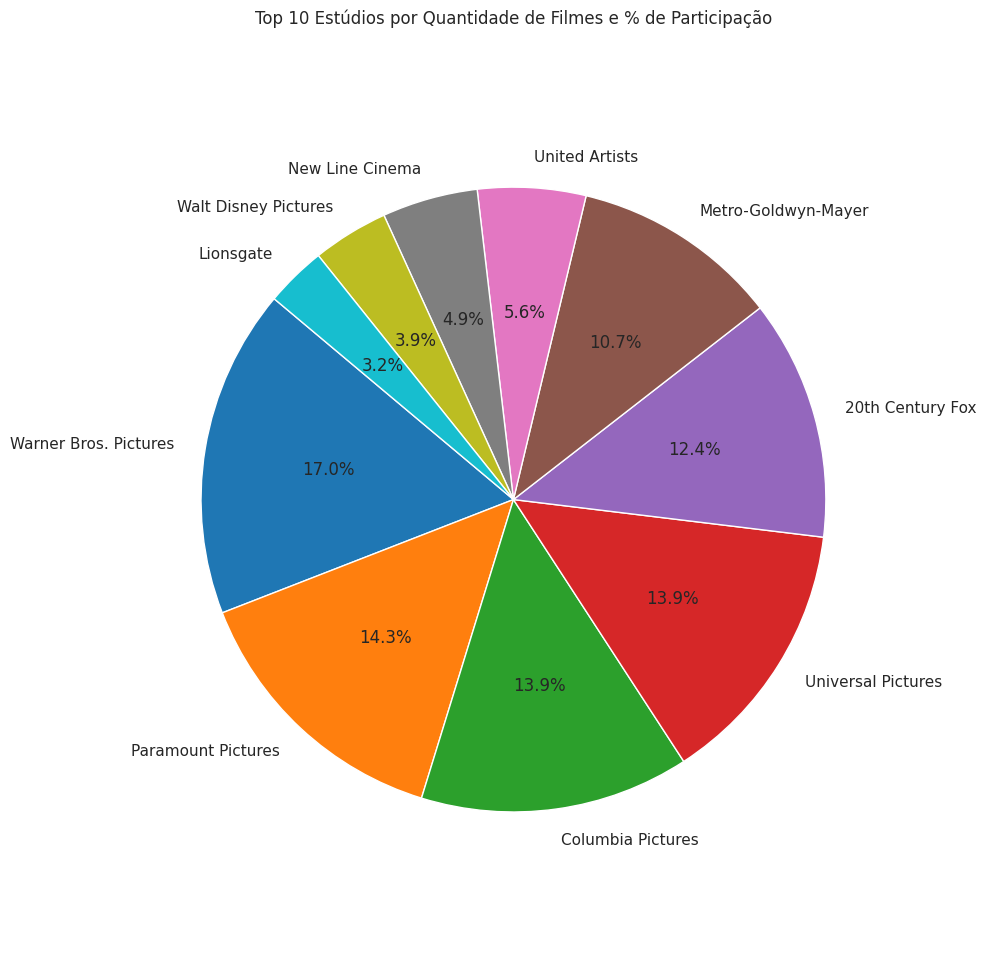

In [80]:
# 2º Problema de visualização - Quais são os 10 estúdios com maior participação na produção total de filmes?
plt.figure(figsize=(10, 10))
plt.pie(
    top_studios['Filmes'],
    labels=top_studios['Studio'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.tab10.colors
)
plt.title('Top 10 Estúdios por Quantidade de Filmes e % de Participação')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 2º Base de dados - COVID19

In [81]:
# lendo e visualizando o dataset
df_covid = pd.read_csv("owid-covid-data.csv")
df_covid.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-02-24,5.0,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-02-25,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-02-26,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-02-27,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-02-28,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,37.746,0.5,64.83,0.511,NaN,NaN,NaN,NaN


In [82]:
# tamanho do dataset
df_covid.shape

(166326, 67)

In [83]:
# valores ausentes
df_covid.isnull().sum()

,0
iso_code,0
continent,9956
location,0
date,0
total_cases,3033
...,...
human_development_index,30073
excess_mortality_cumulative_absolute,160630
excess_mortality_cumulative,160630
excess_mortality,160630


In [84]:
# resumo do dataset
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166326 entries, 0 to 166325
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    166326 non-null  object 
 1   continent                                   156370 non-null  object 
 2   location                                    166326 non-null  object 
 3   date                                        166326 non-null  object 
 4   total_cases                                 163293 non-null  float64
 5   new_cases                                   163133 non-null  float64
 6   new_cases_smoothed                          161150 non-null  float64
 7   total_deaths                                145451 non-null  float64
 8   new_deaths                                  145487 non-null  float64
 9   new_deaths_smoothed                         143390 non-null  float64
 

In [85]:
# colunas do dataset
df_covid.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [86]:
# filtrando o dataset para obter apenas dados do Brasil
df_covid_bra = df_covid[df_covid['location'] == "Brazil"]
df_covid_bra

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
21309,BRA,South America,Brazil,2020-02-26,1.0,1.0,NaN,NaN,NaN,NaN,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN
21310,BRA,South America,Brazil,2020-02-27,1.0,0.0,NaN,NaN,NaN,NaN,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN
21311,BRA,South America,Brazil,2020-02-28,1.0,0.0,NaN,NaN,NaN,NaN,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN
21312,BRA,South America,Brazil,2020-02-29,2.0,1.0,NaN,NaN,NaN,NaN,...,10.1,17.9,NaN,2.2,75.88,0.765,7049.6,3.31,5.25,32.943066
21313,BRA,South America,Brazil,2020-03-01,2.0,0.0,NaN,NaN,NaN,NaN,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22043,BRA,South America,Brazil,2022-03-01,28818850.0,22279.0,65271.286,649922.0,246.0,598.143,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN
22044,BRA,South America,Brazil,2022-03-02,28846495.0,27645.0,50451.286,650254.0,332.0,505.714,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN
22045,BRA,South America,Brazil,2022-03-03,28906672.0,60177.0,45348.143,650824.0,570.0,445.857,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN
22046,BRA,South America,Brazil,2022-03-04,28978052.0,71380.0,42625.857,651522.0,698.0,432.286,...,10.1,17.9,NaN,2.2,75.88,0.765,NaN,NaN,NaN,NaN


In [107]:
# 1º problema de visualização - Qual a quantidade de casos e mortes por dia no Brasil?

df_covid['date'] = pd.to_datetime(df_covid['date'])

df_filtered_covid = df_covid_bra[['date', 'new_cases', 'new_deaths']].copy()
df_filtered_covid['new_cases'] = df_filtered_covid['new_cases'].fillna(0)
df_filtered_covid['new_deaths'] = df_filtered_covid['new_deaths'].fillna(0)

df_long = df_filtered_covid.melt(
    id_vars='date',
    value_vars=['new_cases', 'new_deaths'],
    var_name='Tipo',
    value_name='Quantidade'
)

df_long['Tipo'] = df_long['Tipo'].replace({
    'new_cases': 'Novos Casos',
    'new_deaths': 'Novas Mortes'
})

fig = px.line(
    df_long,
    x='date',
    y='Quantidade',
    color='Tipo',
    title='Novos Casos e Novas Mortes por COVID-19 no Brasil ao longo do tempo',
    labels={'date': 'Data', 'Quantidade': 'Quantidade'}
)

fig.update_traces(mode='lines')
fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
)

fig.show()


In [108]:
# visualizando o problema 1 com foco na segunda onda da covid 19

df_covid_bra['date'] = pd.to_datetime(df_covid_bra['date'])
mask = (df_covid_bra['date'] >= '2021-01-01') & (df_covid_bra['date'] <= '2021-05-31')
df_filtered_covid = df_covid_bra.loc[mask].copy()

df_filtered_covid['new_cases'] = df_filtered_covid['new_cases'].fillna(0)
df_filtered_covid['new_deaths'] = df_filtered_covid['new_deaths'].fillna(0)

df_long = df_filtered_covid.melt(
    id_vars='date',
    value_vars=['new_cases', 'new_deaths'],
    var_name='Tipo',
    value_name='Quantidade'
)

df_long['Tipo'] = df_long['Tipo'].replace({
    'new_cases': 'Novos Casos',
    'new_deaths': 'Novas Mortes'
})

fig = px.line(
    df_long,
    x='date',
    y='Quantidade',
    color='Tipo',
    title='COVID-19 no Brasil: Novos Casos e Novas Mortes (Jan-Mai 2021)',
    labels={'date': 'Data', 'Quantidade': 'Quantidade'}
)

fig.update_traces(mode='lines+markers')
fig.update_layout(hovermode='x unified')

fig.show()


In [89]:
# 2º problema de visualização - Qual o percentual da população brasileira vacinada ao longo do tempo?

df_covid_bra['date'] = pd.to_datetime(df_covid_bra['date'])
df_area = df_covid_bra[['date', 'population', 'people_vaccinated']].copy()
df_area['people_vaccinated'] = df_area['people_vaccinated'].fillna(0)
date_range = pd.date_range(start=df_area['date'].min(), end=df_area['date'].max())
df_area = df_area.set_index('date').reindex(date_range).rename_axis('date').reset_index()
df_area['population'] = df_area['population'].fillna(method='ffill')
df_area['people_vaccinated'] = df_area['people_vaccinated'].fillna(method='ffill')
df_area['people_vaccinated'] = df_area['people_vaccinated'].cummax().fillna(0)
df_area['pct_vaccinated'] = (df_area['people_vaccinated'] / df_area['population']) * 100
df_area['pct_vaccinated'] = df_area['pct_vaccinated'].clip(upper=100)
df_area['pct_not_vaccinated'] = 100 - df_area['pct_vaccinated']

df_long = df_area.melt(
    id_vars='date',
    value_vars=['pct_vaccinated', 'pct_not_vaccinated'],
    var_name='Categoria',
    value_name='Percentual'
)

df_long['Categoria'] = df_long['Categoria'].map({
    'pct_vaccinated': 'Vacinados (%)',
    'pct_not_vaccinated': 'Não vacinados (%)'
})

fig = px.area(
    df_long,
    x='date',
    y='Percentual',
    color='Categoria',
    title='Cobertura Vacinal (%) ao longo do tempo em relação à População Total',
    labels={'date': 'Data', 'Percentual': 'Percentual (%)'}
)

fig.update_layout(
    template='plotly_white',
    yaxis=dict(ticksuffix='%', range=[0, 100]),
    hovermode='x unified'
)

fig.show()

In [90]:
# 3º problema de visualização - Como evolui o número de pacientes hospitalizados por COVID-19 no mundo ao longo do tempo?

df_covid['date'] = pd.to_datetime(df_covid['date'])
df_hosp = df_covid[['date', 'hosp_patients']].copy()
df_hosp['hosp_patients'] = df_hosp['hosp_patients'].fillna(0)
df_hosp = df_hosp.groupby('date', as_index=False).sum()

fig = px.line(
    df_hosp,
    x='date',
    y='hosp_patients',
    title='Número de Pacientes Hospitalizados por COVID-19 no MUNDO ao Longo do Tempo',
    labels={'date': 'Data', 'hosp_patients': 'Pacientes Hospitalizados'}
)

fig.update_layout(
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

## 3º Base de dados - City temperature

In [91]:
# lendo e visualizando o dataset
df_new_weather = pd.read_csv("city_temperature.csv")
df_new_weather.head()

,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9


In [92]:
# criando um novo dataset só com dados do USA
df_new_weather_usa = df_new_weather.copy()
df_new_weather_usa = df_new_weather_usa[df_new_weather_usa['Country'] == 'US']

In [93]:
# convertendo a temperatura para Celsius
df_new_weather.drop(["Region", "State"], axis = 1, inplace = True)
df_new_weather = df_new_weather[df_new_weather['AvgTemperature'] != -99]
df_new_weather['Avg_Temp_C'] = ((df_new_weather['AvgTemperature'] - 32) * 5 / 9).round(1)
df_new_weather.drop(["AvgTemperature"], axis = 1, inplace = True)
df_new_weather.head()

,Country,City,Month,Day,Year,Avg_Temp_C
0,Algeria,Algiers,1,1,1995,17.9
1,Algeria,Algiers,1,2,1995,9.7
2,Algeria,Algiers,1,3,1995,9.3
3,Algeria,Algiers,1,4,1995,8.0
4,Algeria,Algiers,1,5,1995,8.8


In [94]:
# Resumo do dataset
df_new_weather.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2826655 entries, 0 to 2906326
Data columns (total 6 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Country     object 
 1   City        object 
 2   Month       int64  
 3   Day         int64  
 4   Year        int64  
 5   Avg_Temp_C  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 151.0+ MB


In [95]:
# verficando os países existentes no dataset
df_new_weather['Country'].unique()

array(['Algeria', 'Burundi', 'Benin', 'Central African Republic', 'Congo',
       'Egypt', 'Ethiopia', 'Gabon', 'Gambia', 'Guinea', 'Guinea-Bissau',
       'Ivory Coast', 'Kenya', 'Morocco', 'Madagascar', 'Mauritania',
       'Malawi', 'Mozambique', 'Namibia', 'Nigeria', 'Senegal',
       'Sierra Leone', 'South Africa', 'Togo', 'Tunisia', 'Tanzania',
       'Uganda', 'Zambia', 'Bangladesh', 'China', 'Hong Kong', 'India',
       'Indonesia', 'Japan', 'Kazakhstan', 'Kyrgyzstan', 'Laos',
       'Malaysia', 'Mongolia', 'Myanmar (Burma)', 'Nepal', 'North Korea',
       'Pakistan', 'Philippines', 'Singapore', 'South Korea', 'Sri Lanka',
       'Taiwan', 'Tajikistan', 'Thailand', 'Turkmenistan', 'Uzbekistan',
       'Vietnam', 'Australia', 'New Zealand', 'Albania', 'Austria',
       'Belarus', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany',
       'Georgia', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy',
       'Latvia', 'Ma

In [96]:
# criando copia para o gráfico de heatmap
df_weather_heatmap = df_new_weather.copy()

In [97]:
# criando uma nova coluna de datas em formato datetime
df_weather_heatmap['date_str'] = (
    df_weather_heatmap['Year'].astype(str) + '-' +
    df_weather_heatmap['Month'].astype(str).str.zfill(2) + '-' +
    df_weather_heatmap['Day'].astype(str).str.zfill(2)
)

df_weather_heatmap['date_ymd'] = pd.to_datetime(df_weather_heatmap['date_str'], errors='coerce')

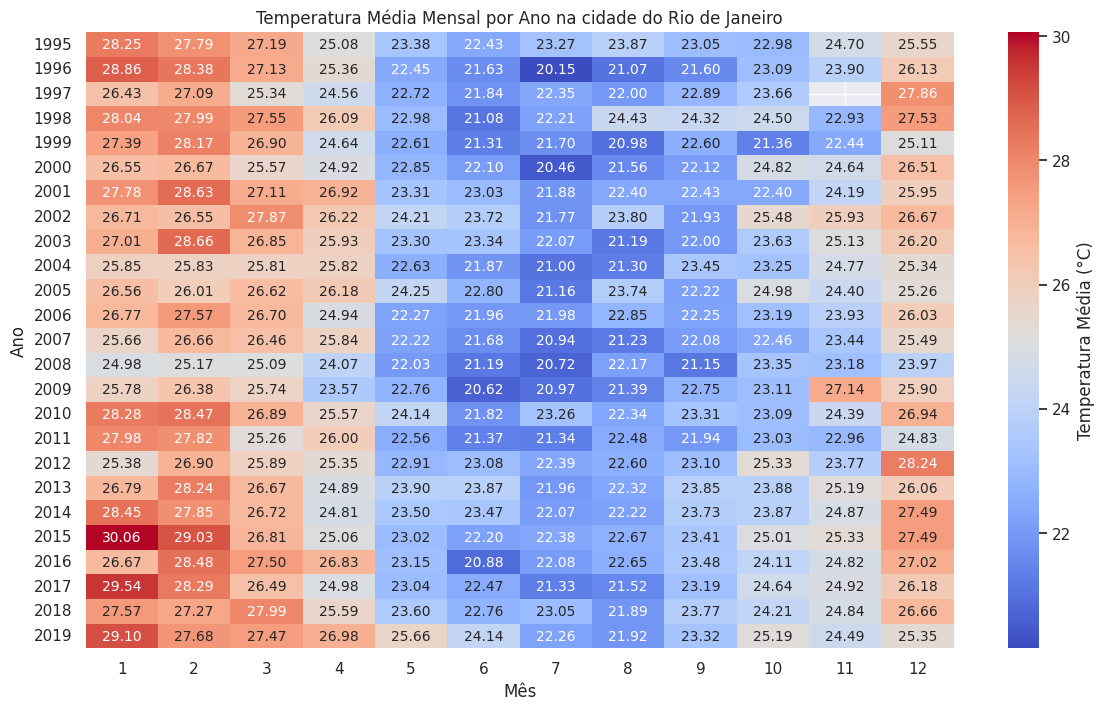

In [109]:
# 1º Problema de visualização de dados - Como variou a temperatura média mensal no Rio de Janeiro entre 1995 e 2019?

city_sample = df_weather_heatmap[df_weather_heatmap['Country'] == 'Brazil']
city_sample = city_sample[city_sample['City'] == 'Rio de Janeiro']
city_sample['month'] = city_sample['date_ymd'].dt.month
city_sample['year'] = city_sample['date_ymd'].dt.year

heatmap_data = city_sample.pivot_table(index='year', columns='month', values='Avg_Temp_C', aggfunc='mean')
heatmap_data = heatmap_data.drop(index=2020)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".2f", cbar_kws={'label': 'Temperatura Média (°C)'}, annot_kws={"size": 10})
plt.title('Temperatura Média Mensal por Ano na cidade do Rio de Janeiro')
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.show()

In [110]:
# 2º Problema de visualização de dados - Qual a tendência da temperatura média global entre 1995 e 2019?
df_new_weather = df_new_weather[df_new_weather['Year'] < 2020]
data = df_new_weather[['Year', 'Avg_Temp_C']].groupby('Year').mean()

# Ajuste linear
linfit = np.polyfit(data.index, data['Avg_Temp_C'], deg=1)
fit_line = linfit[0] * data.index + linfit[1]

# Gráfico da linha de temperatura média (pontilhada, cor clara)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data.index,
    y=data['Avg_Temp_C'],
    mode='lines',
    name='Temperatura Média',
    line=dict(color='lightgray', dash='dot')
))

# Adicionar linha de tendência (vermelha, sólida, espessa)
fig.add_trace(go.Scatter(
    x=data.index,
    y=fit_line,
    mode='lines',
    name='Tendência Linear',
    line=dict(color='red', width=3)
))

# Layout final
fig.update_layout(
    title='Temperatura Média Global (1995–2019)',
    xaxis_title='Ano',
    yaxis_title='Temperatura Média (°C)',
    legend_title='Legenda',
    template='plotly_white'
)

fig.show()

In [100]:
# transformando a temperatura do dataset do USA para Celsius
df_new_weather_usa = df_new_weather_usa[df_new_weather_usa['AvgTemperature'] != -99]
df_new_weather_usa['Avg_Temp_C'] = ((df_new_weather_usa['AvgTemperature'] - 32) * 5 / 9).round(1)
df_new_weather_usa.drop(["AvgTemperature"], axis = 1, inplace = True)
df_new_weather_usa

,Region,Country,State,City,Month,Day,Year,Avg_Temp_C
1450990,North America,US,Alabama,Birmingham,1,1,1995,10.4
1450991,North America,US,Alabama,Birmingham,1,2,1995,2.9
1450992,North America,US,Alabama,Birmingham,1,3,1995,0.7
1450993,North America,US,Alabama,Birmingham,1,4,1995,0.7
1450994,North America,US,Alabama,Birmingham,1,5,1995,-3.1
...,...,...,...,...,...,...,...,...
2906322,North America,US,Additional Territories,San Juan Puerto Rico,7,27,2013,28.0
2906323,North America,US,Additional Territories,San Juan Puerto Rico,7,28,2013,27.6
2906324,North America,US,Additional Territories,San Juan Puerto Rico,7,29,2013,29.0
2906325,North America,US,Additional Territories,San Juan Puerto Rico,7,30,2013,28.8


In [101]:
# verificando os estados presentes no dataset do USA
df_new_weather_usa['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Maryland', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois',
       'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming', 'Additional Territories'],
      dtype=object)

In [102]:
# ajustando os nomes dos estados para suas siglas
state_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL',
    'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI',
    'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT',
    'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND',
    'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

In [103]:
# Abreviando os estados e calculando a temperatura média por estado abreviado
df_new_weather_usa['State_Abbr'] = df_new_weather_usa['State'].map(state_to_abbr)
state_avg = df_new_weather_usa.groupby('State_Abbr')['Avg_Temp_C'].mean().reset_index()

In [104]:
# 3º Problema de Visualização de dados - Como a temperatura média anual variou em cada estado dos EUA entre 1995 e 2019?
fig = px.choropleth(
    state_avg,
    locations='State_Abbr',
    locationmode='USA-states',
    color='Avg_Temp_C',
    color_continuous_scale='RdYlBu_r',
    scope='usa',
    labels={'Avg_Temp_C': 'Temp. Média (°C)'},
    title='Temperatura Média por Estado nos EUA (1995-2019)'
)

fig.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    plot_bgcolor='white',
    margin={"r":0,"t":40,"l":0,"b":0},
    width=1000
)

fig.show()